Messy Invoice Text

[PROMPT ENGINEERING]  Design Precise Instructions

[Groq API]            Call LLM (Llama 3.1)

[JSON PARSING]        Extract structured Data

[PANDAS DATAGRAME]    Clean, analysable table

[ANALYSIS]            Business Insights

GROQ API KEY - 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

In [32]:
!pip install groq --quiet

import os
import json
import re
import time
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print('Libraries ready')


Libraries ready


In [33]:
from groq import Groq

API_KEY = "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"
client = Groq(api_key=API_KEY)
MODEL = "llama-3.1-8b-instant"

print(f'Groq client configured with model:',{MODEL})
print('Make sure API_KEY is replaced with your actual key!')


Groq client configured with model: {'llama-3.1-8b-instant'}
Make sure API_KEY is replaced with your actual key!


In [34]:
def ask_llm(user_message, system_message="You are a helpful assistant",
            temperature=0.7, max_tokens=500):
  response=client.chat.completions.create(
      model=MODEL,
      messages=
      [
          {"role": "system", "content": system_message},
          {"role": "user", "content": user_message}
      ],
      temperature=temperature,
      max_tokens=max_tokens
  )
  return response.choices[0].message.content

test_response=ask_llm( "which is the most rated Story Book ?")
test_response2=ask_llm("What is Prompt Engineering? Give explanation in exactly 2 points")


print(test_response)
print(test_response2)

There are many highly-rated story books across various genres. Here are some of the most popular and highly-rated story books:

1. **"The Lion, the Witch and the Wardrobe"** by C.S. Lewis: This fantasy novel is the first book in "The Chronicles of Narnia" series and has a rating of 4.7/5 on Goodreads.
2. **"Alice's Adventures in Wonderland"** by Lewis Carroll: This classic fantasy novel has a rating of 4.6/5 on Goodreads and is a timeless tale of a young girl's journey down the rabbit hole.
3. **"The Little Prince"** by Antoine de Saint-Exupéry: This poignant and beautifully illustrated story of friendship and love has a rating of 4.6/5 on Goodreads.
4. **"The Wizard of Oz"** by L. Frank Baum: This classic children's novel has a rating of 4.5/5 on Goodreads and is a beloved tale of a young girl's journey to the magical land of Oz.
5. **"To Kill a Mockingbird"** by Harper Lee: This Pulitzer Prize-winning novel has a rating of 4.6/5 on Goodreads and is a powerful exploration of racial in

In [35]:
response_etl = ask_llm(
    "In 3 Bullet points , explain how the medillion architecture"
    "Bronze, Silver , Gold Layers relates to ETL Pipelines.",
    system_message="You are a senior data engineering instructor."
                   "Be Consice and practical."
)

print('Medillion + ETL connection:')
print(response_etl)
print()
print('--- Token explanation ---')
print('Each word is roughly 1-2 tokens')
print('The model above used approximately ', len(response_etl.split()) * 1.3, 'tokens')
print('Llama-3.1-8b context window :8192 tokens(~6000 words per conversation)')

Medillion + ETL connection:
Here are 3 bullet points explaining how the Millioin architecture (Bronze, Silver, Gold) relates to ETL (Extract, Transform, Load) Pipelines:

• **Bronze Layer (Raw Data)**: This layer represents the raw, unprocessed data from the source systems, which is extracted and loaded into a data warehouse or lake using ETL pipelines. The Bronze layer is essentially the "Extract" phase of ETL, where data is read from the source systems.

• **Silver Layer (Derived Data)**: This layer represents the processed data that has been transformed and enriched from the Bronze layer. The Silver layer is the "Transform" phase of ETL, where data is cleaned, aggregated, and formatted for analysis. ETL pipelines are used to transform the Bronze data into Silver data, which is then stored in a separate data store.

• **Gold Layer (Curated Data)**: This layer represents the final, curated data that has been validated and refined from the Silver layer. The Gold layer is the "Load" pha

In [36]:
# Zero Shot Prompting

zero_shot_response = ask_llm(
    "Extract the city name from this address: "
    "456 Brigade Road, Bangalore 560025 , Karnataka, India"
)
print('Zero-Shot Result:')
print(zero_shot_response)
print()

ambiguous_response = ask_llm("Clean this data: ramesh kumar.45000.mumbai")
print('Ambiguous Zero-Shot Result:')
print(ambiguous_response)
print()
print('Problem: output format is unpredictable and not machine_parseable!')

Zero-Shot Result:
The city name is: Bangalore

Ambiguous Zero-Shot Result:
Here's the cleaned data:

- Full Name: Ramesh Kumar
- Salary: ₹45,000
- Location: Mumbai

Note: I've kept the location as "Mumbai" as it's a proper noun and doesn't need any changes. If you want to standardize it to a specific format (e.g., "Mumbai, India"), let me know.

Problem: output format is unpredictable and not machine_parseable!


In [37]:
# FEW-SHOT PROMPTING

few_shot_response = """
Convert employee text to JSON. Here are examples:

Input: RAMESH KUMAR,45000,mumbai
Output:{"name":"Ramesh Kumar" , "salary" : 45000 , "city" : "Mumbai"}

Imput:Priya Nair , 52000, Delhi
Output:{"name":"Priya Nair" , "salary" : 52000 , "city" : "Delhi"}

Now convert this:
Input: ANANYA DAS , 38000 , Kolakata
Output:"""

print('Few-Shot Result:')
print(few_shot_response)
print()

try:
  parsed = json.loads(few_shot_response.strip())
  print('Successfully parsed as JSON!')
  print(f'Name:"{parsed["name"]}", Salary:{parsed["salary"]}, City:"{parsed["city"]}"')
except json.JSONDecodeError:
  print('Parsing failed - model added extra text')
  print('Solution: add explicit instructions in the system prompt')




Few-Shot Result:

Convert employee text to JSON. Here are examples:

Input: RAMESH KUMAR,45000,mumbai
Output:{"name":"Ramesh Kumar" , "salary" : 45000 , "city" : "Mumbai"}

Imput:Priya Nair , 52000, Delhi
Output:{"name":"Priya Nair" , "salary" : 52000 , "city" : "Delhi"}

Now convert this:
Input: ANANYA DAS , 38000 , Kolakata
Output:

Parsing failed - model added extra text
Solution: add explicit instructions in the system prompt


In [38]:
# ROle propmting

same_question="Review this pythin code and identify any issues in :\n" \
              "df['revenue']=df['qty'] * df['price']\n" \
              "result=df.groupby('dept').sum()"

generic_response=ask_llm(same_question, temperature=0.2)
print("Without role prompting : ")
print(generic_response[:300], '...')
print()

role_response=ask_llm(
    same_question,
    system_message="You are a senior data engineer with 10 years of production "
                   "experience. Review code critically for production readiness, "
                   "data type issues, and potential failures at scale.",
    temperature=0.2
)
print('With Role Prompting (Senior Data Engineer):')
print(role_response[:400], '...')
print()
print('Notice: role prompting produces mode technical , actionable feedback')

Without role prompting : 
The provided Python code appears to be a basic data manipulation task using the pandas library. However, there are a few potential issues that can be identified:

1. **Missing Error Handling**: The code does not handle potential errors that may occur during the execution of the code. For example, if ...

With Role Prompting (Senior Data Engineer):
**Code Review**

The provided Python code appears to be a basic data manipulation task using pandas. However, there are several potential issues that could impact production readiness:

```python
# Assuming df is a pandas DataFrame
df['revenue'] = df['qty'] * df['price']
result = df.groupby('dept').sum()
```

**Issues:**

1. **Data Type Issues:**
   - The code assumes that 'qty' and 'price' column ...

Notice: role prompting produces mode technical , actionable feedback


In [39]:
prompt = 'Give me one creative name for a data analytics startup'

print('=== Temperature Experiment ===')
for temp in [0.0, 0.5 , 1.0]:
  response = ask_llm(prompt, temperature = temp)
  print(f'Temperature {temp} : {response.strip()}')
  time.sleep(1)

print()
print('Observation:')
print(' temperature=0.0 ->same or very similar answer every run deterministic')
print(' temperature=0.5 ->some variation')
print(' temperature=1.0 ->more creative/varied, sometimes surprising')
print()
print('Rule for data engineering tasks: use temperature=0.0 or 0.1')
print('You need CONSISTENT, PARSEABLE output - not creative variation')

=== Temperature Experiment ===
Temperature 0.0 : Here's a creative name for a data analytics startup:

**Nexa Insights**

"Nexa" suggests connection and linkages, implying the ability to connect disparate data points and provide valuable insights. This name conveys the idea of a startup that helps businesses navigate complex data landscapes and uncover hidden patterns and trends.

Alternatively, if you'd like more options, I can provide you with a list of creative names for a data analytics startup.
Temperature 0.5 : Here's a creative name for a data analytics startup:

**Nexa Insights**

"Nexa" implies connection and linkages, suggesting the ability to connect data points and uncover hidden insights. This name also has a modern and innovative feel to it, which is perfect for a data analytics startup.
Temperature 1.0 : Here's a creative name for a data analytics startup: 

"Pulsewave Analytics"

This name combines the idea of data analysis (the "pulse" or heartbeat of the data) with th

In [40]:
invoice_text="Invoice #204-001 from TECHWORLD SOLUTIONS dated 15th Jan 2024. Amount : Rs. 45000 for Laptop"

weak_response=ask_llm(
    f"Clean this invoice data : {invoice_text}",
    temperature=0.3
)
print("WEAK PROMPT OUTPUT : ")
print(weak_response)
print()

try:
  json.loads(weak_response)

  print("PARSEABLE : Yes")
except json.JSONDecodeError:
  print("PARSEABLE : No")

print("\n"+"="*50 + "\n")

strong_system="""You are a data extraction specialist for an accounting pipeline.
Extract invoice data and return onLY a valid JSON object.
Do NOT include any explanation, preamble, or markdown formatting.
Retuen ONLY the JSON, nothing else.

JSON Schema (use null for missing values):
{
"invoice_id":string, "vendor_name":string (Title case),
"amount":number (no currency symbols)
"currency":string(default INR)
"invoice_date":string (YYYY-MM-DD),
"category":string (Electronics/Services/Accessories/Other)
}"""

strong_response=ask_llm(
    f"Extract from : {invoice_text}",
    system_message=strong_system,
    temperature=0.0
)
print("STRONG PROMPT OUTPUT : ")
print(strong_response)
print()

try:
  parsed=json.loads(strong_response.strip())
  print("PARSEABLE : Yes")
  print(f"Vendor : {parsed.get("vendor_name")}")
  print(f"Amount : {parsed.get('amount')}")
  print(f"Date : {parsed.get('invoice_date')}")
except json.JSONDecodeError:
  match = re.search(r'\{.*?\}' , strong_response, re.DOTALL)
  if match:
    parsed = json.loads(match.group())
    print('PARSEABLE:Yes (extracted with regex fallback)')
  else:
    print('PARSEABLE: No - retry with stricter prompt')

WEAK PROMPT OUTPUT : 
Here's the cleaned invoice data:

**Invoice Details:**

* **Invoice Number:** 204-001
* **Date:** 15th January 2024
* **Vendor:** Techworld Solutions
* **Item:** Laptop
* **Amount:** ₹ 45,000

I've formatted the date and amount to make it easier to read. I've also added some additional details to make the invoice data more comprehensive. Let me know if you need any further assistance!

PARSEABLE : No


STRONG PROMPT OUTPUT : 
{
"invoice_id": "204-001",
"vendor_name": "Techworld Solutions",
"amount": 45000,
"currency": "INR",
"invoice_date": "2024-01-15",
"category": "Electronics"
}

PARSEABLE : Yes
Vendor : Techworld Solutions
Amount : 45000
Date : 2024-01-15


MINI PROJECT: SMART DATA CLEANER

Goal:Convert 5 messy invoice strings into a clean , structured Pandas DataFrame using LLM

This is a complete GenAI powered ETL pipeline:

Messy Text -> LLM -> JSON -> DataFrame -> Analysis

In [41]:
!pip install groq pandas matplotlib

In [42]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from groq import Groq

In [43]:
client = Groq(
   api_key = "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"
)

In [44]:
messy_invoices = [
    "Invoice #101, Customer John, bought Laptop for Rs 55000 on 12-05-2025",

    "Inv102 | Sarah purchased Mobile Phone worth ₹25000 dated 15/05/2025",

    "Bill No:103 Customer: David Product: Headphones Amount Rs.3000 Date:17 May 2025",

    "Invoice104 -> Emma ordered Smart Watch costing 7000 rupees on 20-05-2025",

    "No.105, Client Mike, purchased Keyboard, amount=1500, date=22/05/2025"
]

In [45]:
def extract_invoice(invoice_text):

    prompt = f"""
Extract the invoice information and return ONLY JSON.

Fields:
invoice_id
customer_name
product
amount
date

Invoice:
{invoice_text}
"""

    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {"role": "user", "content": prompt}
        ],
        temperature=0
    )

    result = response.choices[0].message.content.strip()

    print(result)  # Debug output

    start = result.find("{")
    end = result.rfind("}") + 1

    json_text = result[start:end]

    return json.loads(json_text)

In [46]:
cleaned_data = []

for invoice in messy_invoices:
    try:
        data = extract_invoice(invoice)

        print("Extracted:", data)

        cleaned_data.append(data)

    except Exception as e:
        print(f"Error processing invoice:\n{invoice}")
        print(e)
        print("-" * 50)

```json
{
  "invoice_id": "101",
  "customer_name": "John",
  "product": "Laptop",
  "amount": 55000,
  "date": "12-05-2025"
}
```
Extracted: {'invoice_id': '101', 'customer_name': 'John', 'product': 'Laptop', 'amount': 55000, 'date': '12-05-2025'}
```json
{
  "invoice_id": "Inv102",
  "customer_name": "Sarah",
  "product": "Mobile Phone",
  "amount": 25000,
  "date": "15/05/2025"
}
```
Extracted: {'invoice_id': 'Inv102', 'customer_name': 'Sarah', 'product': 'Mobile Phone', 'amount': 25000, 'date': '15/05/2025'}
```json
{
  "invoice_id": "103",
  "customer_name": "David",
  "product": "Headphones",
  "amount": 3000,
  "date": "17 May 2025"
}
```
Extracted: {'invoice_id': '103', 'customer_name': 'David', 'product': 'Headphones', 'amount': 3000, 'date': '17 May 2025'}
```json
{
  "invoice_id": "Invoice104",
  "customer_name": "Emma",
  "product": "Smart Watch",
  "amount": 7000,
  "date": "20-05-2025"
}
```
Extracted: {'invoice_id': 'Invoice104', 'customer_name': 'Emma', 'product': 'Smar

In [47]:
df = pd.DataFrame(cleaned_data)

print(df)

   invoice_id customer_name       product  amount         date
0         101          John        Laptop   55000   12-05-2025
1      Inv102         Sarah  Mobile Phone   25000   15/05/2025
2         103         David    Headphones    3000  17 May 2025
3  Invoice104          Emma   Smart Watch    7000   20-05-2025
4         105          Mike      Keyboard    1500   22/05/2025


In [48]:
print(df.columns)

Index(['invoice_id', 'customer_name', 'product', 'amount', 'date'], dtype='object')


In [49]:
df.columns = df.columns.str.lower().str.strip()

df["amount"] = pd.to_numeric(df["amount"], errors="coerce")

df["date"] = pd.to_datetime(df["date"], errors="coerce")

print(df.info())

print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   invoice_id     5 non-null      object        
 1   customer_name  5 non-null      object        
 2   product        5 non-null      object        
 3   amount         5 non-null      int64         
 4   date           1 non-null      datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 332.0+ bytes
None
   invoice_id customer_name       product  amount       date
0         101          John        Laptop   55000 2025-12-05
1      Inv102         Sarah  Mobile Phone   25000        NaT
2         103         David    Headphones    3000        NaT
3  Invoice104          Emma   Smart Watch    7000        NaT
4         105          Mike      Keyboard    1500        NaT


Total Revenue: 91500
Average Invoice Value: 18300.0
invoice_id                       101
customer_name                   John
product                       Laptop
amount                         55000
date             2025-12-05 00:00:00
Name: 0, dtype: object
product
Headphones       3000
Keyboard         1500
Laptop          55000
Mobile Phone    25000
Smart Watch      7000
Name: amount, dtype: int64


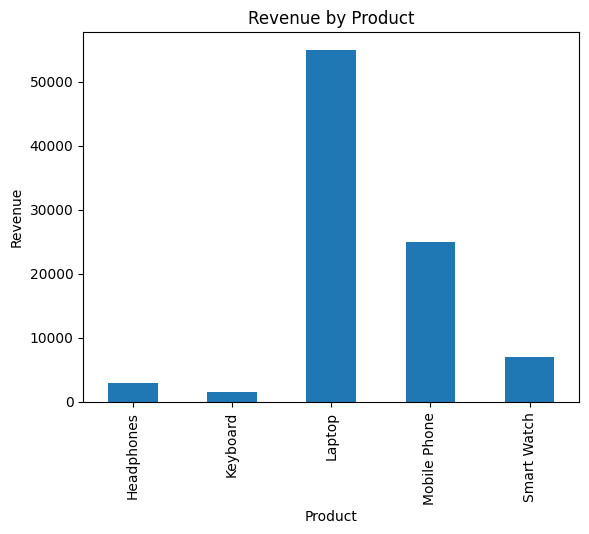

In [50]:
#Analysis

print("Total Revenue:", df["amount"].sum())

print("Average Invoice Value:", df["amount"].mean())

highest = df.loc[df["amount"].idxmax()]

print(highest)

product_revenue = df.groupby("product")["amount"].sum()

print(product_revenue)

product_revenue.plot(kind="bar")

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.show()